In [3]:
import pandas as pd
import numpy as np

In [4]:
df = pd.read_csv("titanic_cleaned.csv")

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Unknown,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Unknown,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Unknown,Southampton,no,True


In [5]:
df.shape

(889, 15)

In [6]:
X = df.drop(columns=['survived'])
y  = df['survived']

Step 7 : Stratified train/test split

In [7]:
print(y.value_counts())

print("\n Class percentage :,")

print(y.value_counts(normalize=True)*100)

0    549
1    340
Name: survived, dtype: int64

 Class percentage :,
0    61.754781
1    38.245219
Name: survived, dtype: float64


In [8]:
from sklearn.model_selection import train_test_split

X_train , X_test , y_train , y_test  = train_test_split(X,y, test_size=0.2, random_state=42 , stratify=y)

In [9]:
print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting class distribution:")
print(y_test.value_counts(normalize=True))

Training shape: (711, 14)
Testing shape: (178, 14)

Training class distribution:
0    0.61744
1    0.38256
Name: survived, dtype: float64

Testing class distribution:
0    0.617978
1    0.382022
Name: survived, dtype: float64


### Why stratification?

The target variable `survived` contains two classes: passengers who did not survive and passengers who survived. Stratification preserves
approximately the same class proportions in both the training and testing datasets, making the evaluation more representative of the
original class distribution.

Step 8 : Preprocessing pipeline

In [10]:
numeric_features = [
    'age',
    'pclass',
    'sibsp',
    'parch',
    'fare'
]

categorical_features = [
    'sex',
    'embarked',
    'deck'
]

In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [12]:
numeric_pipeline  = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler' , StandardScaler())
])

In [13]:
categorical_pipline  = Pipeline([
   ('imputer', SimpleImputer(strategy='most_frequent')),
   ('encoder' , OneHotEncoder(handle_unknown='ignore'))
    ])

In [14]:
preprocessor  = ColumnTransformer([
    ('num',numeric_pipeline,numeric_features),
    ('cat',categorical_pipline,categorical_features)
])

This ensures the preprocessing is fitted as part of the model pipeline rather than manually fitting on the entire dataset.

Step 9 :Train 3 classifiers

In [15]:
from sklearn.linear_model import LogisticRegression

logistic_pipeline = Pipeline([
    ('preprocessor',preprocessor),
    ('model',LogisticRegression(max_iter=1000,random_state=42))
])

logistic_pipeline.fit(X_train , y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'pclass', 'sibsp',
                                                   'parch', 'fare']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['sex', 'embarked',
                                                   'deck'])])),
                ('model', LogisticRegression(max_iter=1000, random_state=42))])

In [16]:
from sklearn.tree import DecisionTreeClassifier

tree_pipeline = Pipeline([
    ('preprocessor',preprocessor),
    ('model',DecisionTreeClassifier(random_state=42 , max_depth=5))
])

tree_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'pclass', 'sibsp',
                                                   'parch', 'fare']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['sex', 'embarked',
                                                   'deck'])])),
                ('model',
                 DecisionTreeClassifier(max_depth=5, random_state=42))])

In [17]:
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline([
    ('preprocessor',preprocessor),
 ('model',RandomForestClassifier(n_estimators=200,random_state=42,n_jobs=-1))
])

rf_pipeline.fit(X_train , y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'pclass', 'sibsp',
                                                   'parch', 'fare']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['sex', 'embarked',
                                                   'deck'])])),
                ('model',
                 RandomForestClassifier(n_estimators=200, n_jobs=-1,
                                        random_state=42))])

In [18]:
X_train_processed = preprocessor.fit_transform(X_train)

feature_names =preprocessor.get_feature_names_out()

tree_model = DecisionTreeClassifier(
   random_state= 42,
   max_depth=5
)


tree_model.fit(X_train_processed , y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

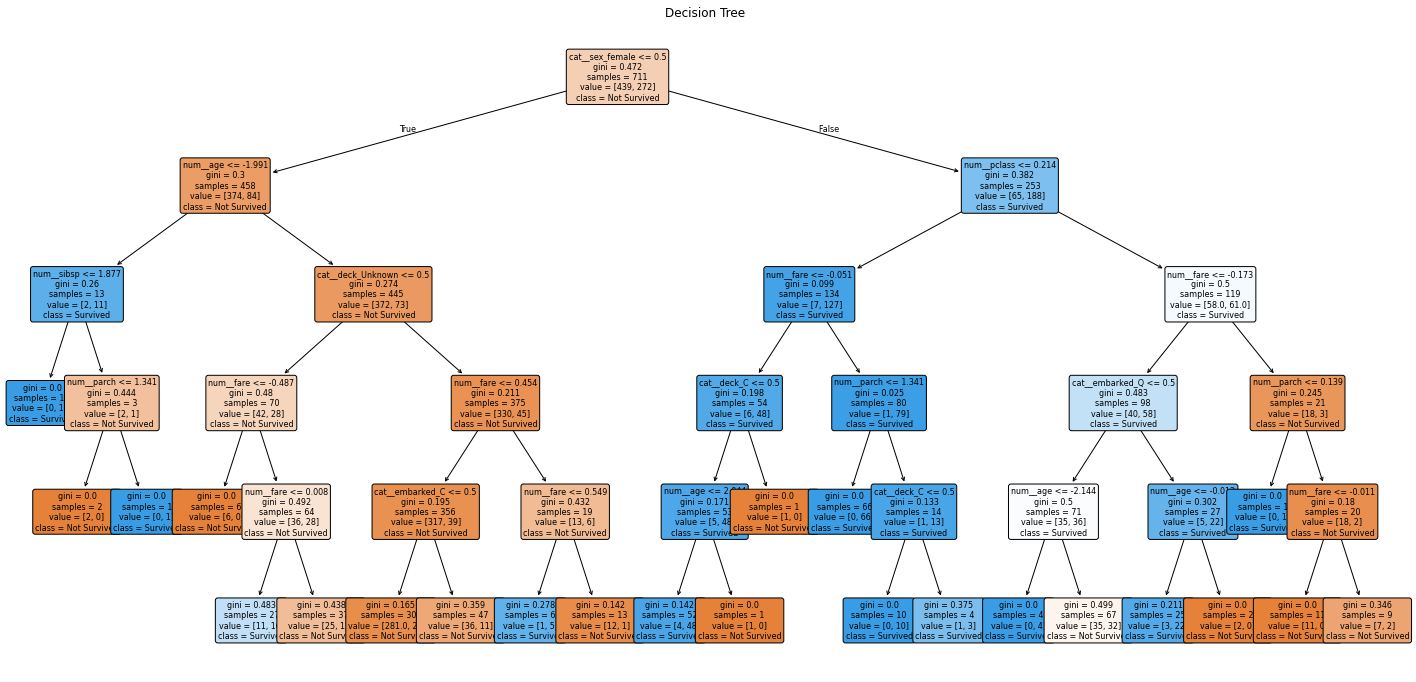

In [19]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(25, 12))

plot_tree(
    tree_model,
    feature_names=feature_names,
    class_names=['Not Survived', 'Survived'],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title('Decision Tree')
plt.show()

Step 10 — Evaluate all three models

In [20]:
from sklearn.metrics import(
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    f1_score,
    roc_curve,
    roc_auc_score
)

In [21]:
def evaluate_model(model , X_test , y_test):

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    cm = confusion_matrix(y_test , y_pred)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test , y_pred)
    auc = roc_auc_score(y_test, y_pred)

    return {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
        'AUC': auc,
        'Confusion Matrix': cm
    }

In [22]:
results = {}

results['Logistic Regression'] = evaluate_model(
    logistic_pipeline,
    X_test,
    y_test
)

results['Decision Tree'] = evaluate_model(
    tree_pipeline,
    X_test,
    y_test
)

results['Random Forest'] = evaluate_model(
    rf_pipeline,
    X_test,
    y_test
)

In [23]:
comparison_df = pd.DataFrame({
    model: {
        'Accuracy': result['Accuracy'],
        'Precision': result['Precision'],
        'Recall': result['Recall'],
        'F1': result['F1'],
        'AUC': result['AUC']
    }
    for model, result in results.items()
}).T

comparison_df

,Accuracy,Precision,Recall,F1,AUC
Logistic Regression,0.825843,0.813559,0.705882,0.755906,0.802941
Decision Tree,0.758427,0.765957,0.529412,0.626087,0.714706
Random Forest,0.803371,0.753846,0.720588,0.736842,0.787567


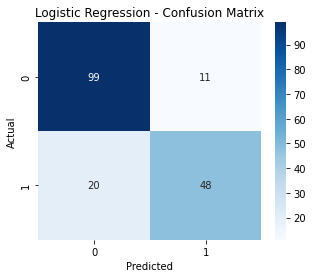

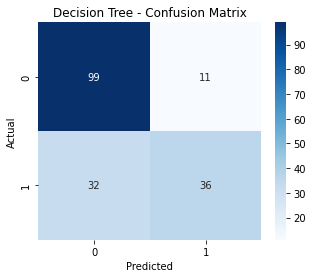

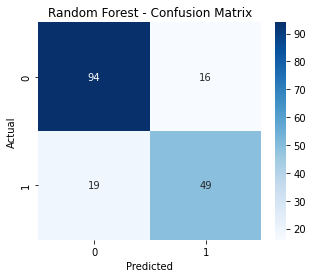

In [24]:
import seaborn as sns


for model_name, result in results.items():
    
    plt.figure(figsize=(5, 4))
    
    sns.heatmap(
        result['Confusion Matrix'],
        annot=True,
        fmt='d',
        cmap='Blues'
    )
    
    plt.title(f'{model_name} - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

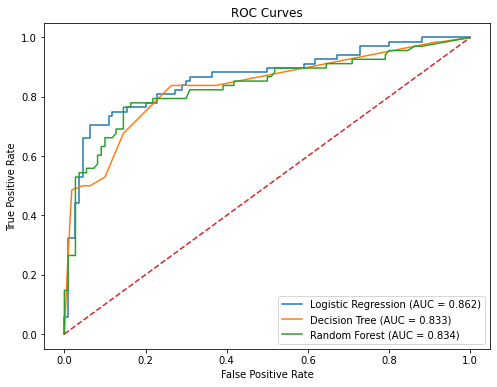

In [25]:
plt.figure(figsize=(8, 6))

for model_name, model in {
    'Logistic Regression': logistic_pipeline,
    'Decision Tree': tree_pipeline,
    'Random Forest': rf_pipeline
}.items():
    
    y_prob = model.predict_proba(X_test)[:, 1]
    
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    
    plt.plot(
        fpr,
        tpr,
        label=f'{model_name} (AUC = {auc:.3f})'
    )

plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()

plt.show()

Step 11 — Imbalance handling

In [26]:
print("Class counts:")
print(y_train.value_counts())

print("\nClass percentages:")
print(y_train.value_counts(normalize=True) * 100)

Class counts:
0    439
1    272
Name: survived, dtype: int64

Class percentages:
0    61.744023
1    38.255977
Name: survived, dtype: float64


In [27]:
baseline_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])

baseline_model.fit(X_train, y_train)

baseline_pred = baseline_model.predict(X_test)

In [28]:
balanced_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(
        max_iter=1000,
        random_state=42,
        class_weight='balanced'
    ))
])

balanced_model.fit(X_train, y_train)

balanced_pred = balanced_model.predict(X_test)

In [29]:
!pip install imbalanced-learn


     -------------------------------------- 258.3/258.3 kB 5.3 MB/s eta 0:00:00



[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [30]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

In [31]:
smote_model = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('model', LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

smote_model.fit(X_train, y_train)

smote_pred = smote_model.predict(X_test)

c:\Users\PRATHYUSHA\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


In [32]:
imbalance_results = pd.DataFrame({
    'Baseline': [
        precision_score(y_test, baseline_pred),
        recall_score(y_test, baseline_pred),
        f1_score(y_test, baseline_pred)
    ],
    
    'Class Weight Balanced': [
        precision_score(y_test, balanced_pred),
        recall_score(y_test, balanced_pred),
        f1_score(y_test, balanced_pred)
    ],
    
    'SMOTE': [
        precision_score(y_test, smote_pred),
        recall_score(y_test, smote_pred),
        f1_score(y_test, smote_pred)
    ]
}, index=['Precision', 'Recall', 'F1'])

imbalance_results

,Baseline,Class Weight Balanced,SMOTE
Precision,0.813559,0.688312,0.716216
Recall,0.705882,0.779412,0.779412
F1,0.755906,0.731034,0.746479


### Imbalance Handling Interpretation

The baseline, class-weighted, and SMOTE approaches were compared using precision, recall, and F1 score. The selected approach should be based on the observed balance between these metrics rather than recall or precision alone. SMOTE was applied only to the training data through the pipeline to prevent information from the test set from influencing the training process.

Step 12 — Random Forest GridSearchCV

In [33]:
from sklearn.model_selection import GridSearchCV

rf_for_grid = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        random_state=42,
        n_jobs=-1,
        oob_score=True
    ))
])

In [34]:
param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [None, 5, 10],
    'model__max_features': ['sqrt', 'log2']
}

In [35]:
grid_search = GridSearchCV(
    estimator=rf_for_grid,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    return_train_score=True
)

grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['age',
                                                                          'pclass',
                                                                          'sibsp',
                                                                          'parch',
                                                                          'fare']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('encoder',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['sex',
                                                                          'embarked',
                                                                          'deck'])])),
                                       ('model',
                                        RandomForestClassifier(n_jobs=-1,
                                                               oob_score=True,
                                                               random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [None, 5, 10],
                         'model__max_features': ['sqrt', 'log2'],
                         'model__n_estimators': [100, 200]},
             return_train_score=True, scoring='f1')

In [36]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'model__max_depth': 10, 'model__max_features': 'sqrt', 'model__n_estimators': 100}


In [37]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'model__max_depth': 10, 'model__max_features': 'sqrt', 'model__n_estimators': 100}


In [38]:
best_rf_pipeline = grid_search.best_estimator_

oob_score = best_rf_pipeline.named_steps['model'].oob_score_

print("OOB Score:", oob_score)

OOB Score: 0.8073136427566807



Step 13 — Regression side task

In [39]:
regression_features = [
    'pclass',
    'sex',
    'age',
    'sibsp',
    'parch',
    'embarked',
    'deck'
]

X_reg = df[regression_features]
y_reg = df['fare']

In [40]:
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42
)

In [42]:
reg_numeric_features = [
    'pclass',
    'age',
    'sibsp',
    'parch'
]

reg_categorical_features = [
    'sex',
    'embarked',
    'deck'
]

In [43]:
reg_numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

reg_categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

In [44]:
reg_preprocessor = ColumnTransformer([
    ('num', reg_numeric_pipeline, reg_numeric_features),
    ('cat', reg_categorical_pipeline, reg_categorical_features)
])

In [45]:
from sklearn.linear_model import LinearRegression

regression_pipeline = Pipeline([
    ('preprocessor', reg_preprocessor),
    ('model', LinearRegression())
])

regression_pipeline.fit(
    X_reg_train,
    y_reg_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['pclass', 'age', 'sibsp',
                                                   'parch']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['sex', 'embarked',
                                                   'deck'])])),
                ('model', LinearRegression())])

In [46]:
y_reg_pred = regression_pipeline.predict(X_reg_test)

In [47]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_reg_test, y_reg_pred)

rmse = np.sqrt(
    mean_squared_error(y_reg_test, y_reg_pred)
)

r2 = r2_score(y_reg_test, y_reg_pred)

n = len(y_reg_test)
p = X_reg_test.shape[1]

adjusted_r2 = 1 - (
    (1 - r2) * (n - 1) / (n - p - 1)
)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)
print("Adjusted R²:", adjusted_r2)

MAE: 16.940421806290104
RMSE: 37.870861893681024
R²: 0.46243160953280615
Adjusted R²: 0.44029644051356875


In [48]:
transformed_X_reg = regression_pipeline.named_steps[
    'preprocessor'
].transform(X_reg_test)

p_transformed = transformed_X_reg.shape[1]

adjusted_r2 = 1 - (
    (1 - r2) * (n - 1) / (n - p_transformed - 1)
)

print("Adjusted R²:", adjusted_r2)

Adjusted R²: 0.4053149680456668


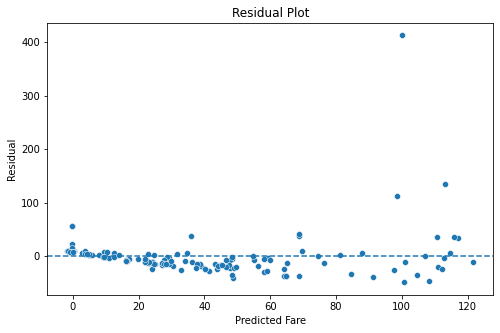

In [49]:
residuals = y_reg_test - y_reg_pred

plt.figure(figsize=(8, 5))

sns.scatterplot(
    x=y_reg_pred,
    y=residuals
)

plt.axhline(
    y=0,
    linestyle='--'
)

plt.xlabel('Predicted Fare')
plt.ylabel('Residual')
plt.title('Residual Plot')

plt.show()

### Residual Analysis

The residual plot is examined to determine whether the residuals are randomly distributed around zero. If the spread of residuals increases or decreases systematically as predicted fare increases, this indicates heteroscedasticity. A roughly constant spread around zero would provide less evidence of heteroscedasticity.

Step 14 — Final model comparison

In [50]:
classification_comparison = comparison_df[
    ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']
].copy()

classification_comparison

,Accuracy,Precision,Recall,F1,AUC
Logistic Regression,0.825843,0.813559,0.705882,0.755906,0.802941
Decision Tree,0.758427,0.765957,0.529412,0.626087,0.714706
Random Forest,0.803371,0.753846,0.720588,0.736842,0.787567


In [51]:
regression_comparison = pd.DataFrame({
    'MAE': [mae],
    'RMSE': [rmse],
    'R²': [r2],
    'Adjusted R²': [adjusted_r2]
}, index=['Linear Regression'])

regression_comparison

,MAE,RMSE,R²,Adjusted R²
Linear Regression,16.940422,37.870862,0.462432,0.405315


In [52]:
best_classifier_name = classification_comparison['F1'].idxmax()

best_classifier_f1 = classification_comparison.loc[
    best_classifier_name,
    'F1'
]

best_classifier_auc = classification_comparison.loc[
    best_classifier_name,
    'AUC'
]

print("Classifier with highest F1:", best_classifier_name)
print("F1:", best_classifier_f1)
print("AUC:", best_classifier_auc)

Classifier with highest F1: Logistic Regression
F1: 0.7559055118110236
AUC: 0.8029411764705883


In [53]:
print(
    f"The classification models were compared using accuracy, precision, "
    f"recall, F1 score, and AUC. Based on the highest observed F1 score, "
    f"{best_classifier_name} achieved an F1 score of "
    f"{best_classifier_f1:.3f} and an AUC of {best_classifier_auc:.3f}. "
    f"The final model selection should also consider the precision and "
    f"recall values and the business importance of false positives versus "
    f"false negatives. The regression model was evaluated separately "
    f"using MAE, RMSE, R², and Adjusted R² because regression and "
    f"classification metrics are not directly comparable."
)

The classification models were compared using accuracy, precision, recall, F1 score, and AUC. Based on the highest observed F1 score, Logistic Regression achieved an F1 score of 0.756 and an AUC of 0.803. The final model selection should also consider the precision and recall values and the business importance of false positives versus false negatives. The regression model was evaluated separately using MAE, RMSE, R², and Adjusted R² because regression and classification metrics are not directly comparable.


Step 15 — Save the complete pipeline

In [54]:
import joblib

full_pipeline = best_rf_pipeline

joblib.dump(
    full_pipeline,
    "titanic_pipeline.joblib"
)

print("Complete pipeline saved successfully.")

Complete pipeline saved successfully.


In [55]:
loaded_pipeline = joblib.load(
    "titanic_pipeline.joblib"
)

print("Pipeline loaded successfully.")

Pipeline loaded successfully.


In [56]:
raw_sample = X_test.head(5)

raw_predictions = loaded_pipeline.predict(raw_sample)

print("Raw input:")
display(raw_sample)

print("\nPredictions:")
print(raw_predictions)

Raw input:


,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
159,3,male,44.0,0,1,16.100,S,Third,man,True,Unknown,Southampton,no,False
125,3,male,28.0,0,0,7.750,Q,Third,man,True,Unknown,Queenstown,no,True
427,3,male,28.0,0,0,7.750,Q,Third,man,True,Unknown,Queenstown,no,True
421,3,male,29.0,0,0,7.875,S,Third,man,True,Unknown,Southampton,no,True
564,3,male,24.0,2,0,24.150,S,Third,man,True,Unknown,Southampton,no,False



Predictions:
[0 0 0 0 0]
